In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("awsaf49/brats20-dataset-training-validation")

print("Path to dataset files:", path)

Path to dataset files: /Users/mariamalghamdi/.cache/kagglehub/datasets/awsaf49/brats20-dataset-training-validation/versions/1


In [2]:
import os
import random

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from vit_pytorch.vit_3d import ViT
from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler
)

from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler
)


from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

from tqdm import tqdm

root = "BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

mapping_file = os.path.join(root,"name_mapping.csv")



random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

root = "BraST2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

if hasattr(torch, "xpu") and torch.xpu.is_available():
    device = torch.device("xpu")
elif torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

os.makedirs("Results/Models",exist_ok=True)

os.makedirs("Results/Metrics", exist_ok=True)

os.makedirs("Results/Figures",exist_ok=True)

os.makedirs("Results/Figures/ViT",exist_ok=True)

os.makedirs("Results/Figures/EfficientNet",exist_ok=True)

os.makedirs("Results/Figures/ViT/GradCAM", exist_ok=True)

os.makedirs("Results/Figures/EfficientNet/GradCAM", exist_ok=True)

os.makedirs("Results/Figures/Comparison", exist_ok=True)

os.makedirs("Results/MC_Metrics", exist_ok=True)

os.makedirs("Results/Figures/Comparison", exist_ok=True)

Using device: mps


In [3]:
print("Loading metadata files...\n")

validation_path = "BraST2020/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/name_mapping_validation_data.csv"
training_path = "BraST2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/name_mapping.csv"

if os.path.exists(validation_path):
    val_df = pd.read_csv(validation_path)
    print("Validation metadata preview:")
    print(val_df.head())
    print()
else:
    print("Validation metadata file not found; continuing with training metadata.\n")

print("Training metadata summary:")
df = pd.read_csv(training_path)
print(df.describe())


Loading metadata files...

Validation metadata preview:
  BraTS_2017_subject_ID BraTS_2018_subject_ID TCGA_TCIA_subject_ID  \
0   Brats17_CBICA_AAM_1   Brats18_CBICA_AAM_1                  NaN   
1   Brats17_CBICA_ABT_1   Brats18_CBICA_ABT_1                  NaN   
2   Brats17_CBICA_ALA_1   Brats18_CBICA_ALA_1                  NaN   
3   Brats17_CBICA_ALT_1   Brats18_CBICA_ALT_1                  NaN   
4   Brats17_CBICA_ALV_1   Brats18_CBICA_ALV_1                  NaN   

  BraTS_2019_subject_ID   BraTS_2020_subject_ID  
0   BraTS19_CBICA_AAM_1  BraTS20_Validation_001  
1   BraTS19_CBICA_ABT_1  BraTS20_Validation_002  
2   BraTS19_CBICA_ALA_1  BraTS20_Validation_003  
3   BraTS19_CBICA_ALT_1  BraTS20_Validation_004  
4   BraTS19_CBICA_ALV_1  BraTS20_Validation_005  

Training metadata summary:
       Grade BraTS_2017_subject_ID BraTS_2018_subject_ID TCGA_TCIA_subject_ID  \
count    369                   285                   285                  167   
unique     2                   28

In [4]:
df = df[["BraTS_2020_subject_ID", "Grade"]].copy()
df.columns = ["patient", "Grade"]

df["Grade"] = df["Grade"].map({"LGG": 0, "HGG": 1}).astype(int)
df.head()


,patient,Grade
0,BraTS20_Training_001,1
1,BraTS20_Training_002,1
2,BraTS20_Training_003,1
3,BraTS20_Training_004,1
4,BraTS20_Training_005,1


In [5]:
patients = sorted(
    [p for p in os.listdir(root) if os.path.isdir(os.path.join(root, p))]
)

modalities = ["t1", "t1ce", "t2", "flair", "seg"]


def load(patient):

    images = {}

    for m in modalities:

        nii_file = os.path.join(
            root,
            patient,
            f"{patient}_{m}.nii"
        )

        nii_gz_file = nii_file + ".gz"

        if os.path.isfile(nii_gz_file):
            file = nii_gz_file

        elif os.path.isfile(nii_file):
            file = nii_file

        else:
            continue

        images[m.upper()] = nib.load(file).get_fdata(
            dtype=np.float32
        )

    return images

def visualise(patient, slices=[25, 50, 75, 100]):
    images = load(patient)

    rows = len(slices)
    cols = len(images)

    plt.figure(figsize=(3 * cols, 3 * rows))

    for c, (name, img) in enumerate(images.items()):
        for r, s in enumerate(slices):
            if s >= img.shape[2]:
                continue

            plt.subplot(rows, cols, r * cols + c + 1)
            plt.imshow(
                img[:, :, s].T,
                cmap="jet" if name == "SEG" else "gray",
                origin="lower",
            )
            plt.title(f"{name} {s}", fontsize=8)
            plt.axis("off")

    plt.suptitle(patient)
    plt.tight_layout()
    plt.show()


dict_keys(['T1', 'T1CE', 'T2', 'FLAIR', 'SEG'])


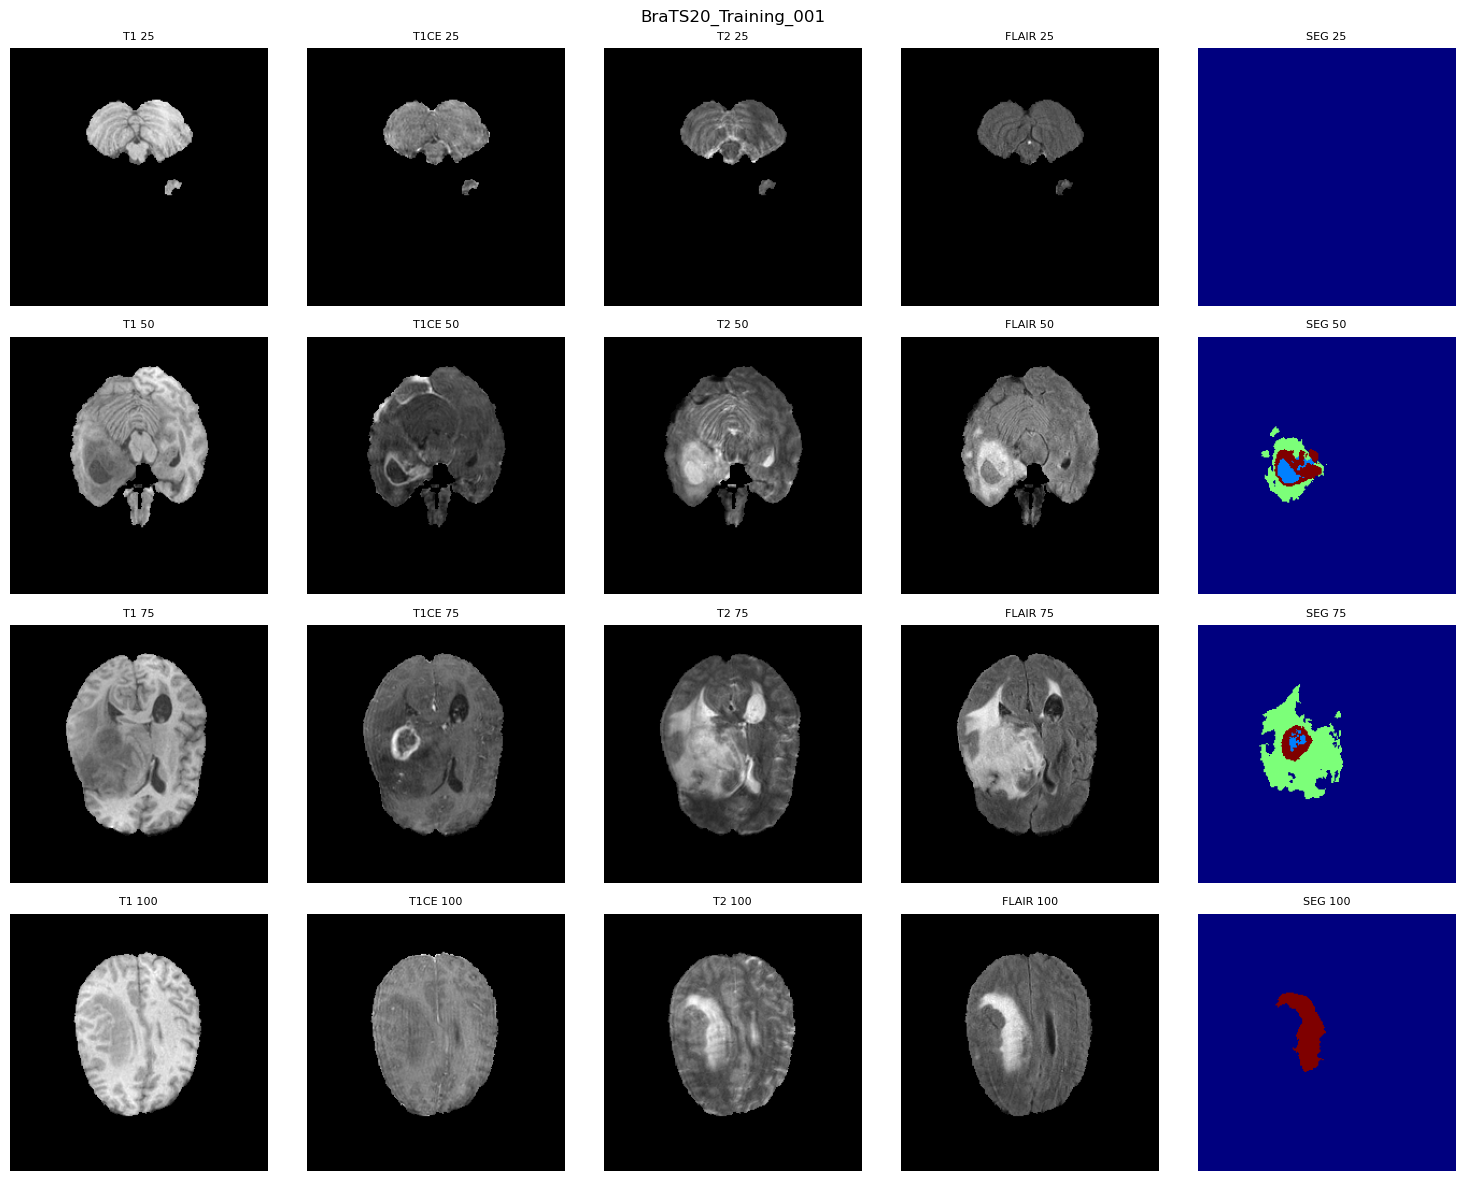

In [6]:
patient = df.patient.iloc[0]

print(load(patient).keys())

visualise(patient)

In [7]:
input_modalities = ["t1", "t1ce", "t2", "flair"]


def normalise(img):
    
    img = img.astype(np.float32)
    
    mask = img > 0

    if mask.any():
        mean = img[mask].mean()
        std = img[mask].std()
        img[mask] = (img[mask] - mean) / (std + 1e-8)
    
    img[~mask] = 0.0
    
    return img


def load_volume(patient):
    folder = os.path.join(root, patient)
    images = []

    for modality in input_modalities:
        file = os.path.join(folder, f"{patient}_{modality}.nii")

        if not os.path.exists(file):
            file += ".gz"

        img = nib.load(file).get_fdata()
        img = normalise(img)
        images.append(img)
        volume = np.stack(images, axis = -1)

    return volume.astype(np.float32)


In [8]:
volume = load_volume(df.iloc[0]["patient"])

print("volume shape: ", volume.shape)

print("data type: ", volume.dtype)

volume shape:  (240, 240, 155, 4)
data type:  float32


In [9]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df.Grade,
    random_state=42,
)

train_df = train_df.reset_index(drop = True)
test_df = test_df.reset_index(drop = True)

print("Training patients:", len(train_df))
print("Testing patients:", len(test_df))

print("\nTraining distribution")
print(train_df["Grade"].value_counts())

print("\nTesting distribution")
print(test_df["Grade"].value_counts())

Training patients: 295
Testing patients: 74

Training distribution
Grade
1    234
0     61
Name: count, dtype: int64

Testing distribution
Grade
1    59
0    15
Name: count, dtype: int64


In [10]:
def prepare_volume(patient):
    volume = load_volume(patient)
    
    volume = torch.from_numpy(volume).float()
    
    volume = volume.permute(3, 2, 0, 1)
    
    volume = volume.unsqueeze(0)
    
    volume = F.interpolate(
		volume,
		size = (96, 96, 96),
		mode = "trilinear",
		align_corners = False
	)
    
    volume = volume.squeeze(0)
    
    return volume

In [11]:
def augment_volume(volume):
    
    if torch.rand(1).item() < 0.5:
        volume = torch.flip(volume, dims = [3])
    
    if torch.rand(1).item() < 0.15:
        volume = torch.flip(volume, dims = [2])
        
    angle = torch.deg2rad(volume.new_tensor(torch.empty(1).uniform_(-10, 10).item()))
    scale = volume.new_tensor(torch.rand(1).item() * 0.1 + 0.95)
    translation_x = volume.new_tensor(torch.rand(1).item() * 0.1 - 0.05)
    translation_y = volume.new_tensor(torch.rand(1).item() * 0.1 - 0.05)
    translation_z = volume.new_tensor(torch.rand(1).item() * 0.1 - 0.05)

    cos_angle = torch.cos(angle)
    sin_angle = torch.sin(angle)
            
    zero = volume.new_tensor(0.0)
    theta = torch.stack(
        [
            torch.stack(
                [
                    cos_angle / scale,
                    -sin_angle / scale,
                    zero,
                    translation_x
                ]
            ),
            torch.stack(
                [
                    sin_angle / scale,
                    cos_angle / scale,
                    zero,
                    translation_y
                ]
            ),
            torch.stack(
                [
                    zero,
                    zero,
                    volume.new_tensor(1.0) / scale,
                    translation_z
                ],
            )
        ],
    ).unsqueeze(0)
    
    volume_batch = volume.unsqueeze(0)
            
    grid = F.affine_grid(
        theta,
        size=volume_batch.size(),
        align_corners=False
    )
            
    volume = F.grid_sample(
        volume_batch,
        grid,
        mode="bilinear",
        padding_mode="zeros",
        align_corners=False,
    ).squeeze(0)

    brightness = torch.empty(1).uniform_(0.85, 1.15).item()
    contrast = torch.empty(1).uniform_(0.85, 1.15).item()
    
    channel_means = volume.mean(dim=(1, 2, 3), keepdim=True)
    volume = ((volume - channel_means) * contrast + channel_means) * brightness
    
    return volume

In [12]:
class BraSTDataSet(Dataset):
    def __init__(self, df, training=True):
        self.df = df.reset_index(drop=True)
        self.training = training

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        
        row = self.df.iloc[index]
        volume = prepare_volume(row.patient)
        
        if self.training:
            volume = augment_volume(volume)


        Grade = torch.tensor(row.Grade, dtype=torch.float32)
            
        return volume, Grade

In [13]:
sample_patient = train_df.iloc[0]["patient"]

original = prepare_volume(sample_patient)

torch.manual_seed(42)

augmented = augment_volume(original.clone())

In [14]:
train_dataset = BraSTDataSet(train_df, training=True)
test_dataset = BraSTDataSet(test_df, training=False)

train_generator = torch.Generator()
train_generator.manual_seed(42)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

print(len(train_df), len(test_df))

print("Training patients:",len(train_df))

print("Testing patients:",len(test_df))


sample_x, sample_y = next(iter(train_loader))


print("Input shape:", sample_x.shape)

print("Target shape:",sample_y.shape)

295 74
Training patients: 295
Testing patients: 74
Input shape: torch.Size([4, 4, 96, 96, 96])
Target shape: torch.Size([4])


In [15]:
vit_model = ViT(
	image_size=96,
	frames=96,
	image_patch_size=16,
	frame_patch_size=16,
	num_classes=1,
	channels=4,
	dim=256,
	depth=4,
	heads=4,
	mlp_dim=512,
	pool='cls',
	dropout=0.4,
	emb_dropout=0.1,
)

criterion = nn.BCEWithLogitsLoss()
optimiser = torch.optim.AdamW(vit_model.parameters(), lr = 1e-4, weight_decay = 1e-5)

vit_model = vit_model.to(device)


Epoch 1/100 Testing: 100%|██████████| 19/19 [00:42<00:00,  2.22s/it, accuracy=0.7973, loss=0.3406]


Epoch 1/100 - Train Accuracy: 0.7932 - Train Loss: 0.5326 - Test Accuracy: 0.7973 - Test Loss: 0.5060


Epoch 2/100 Testing: 100%|██████████| 19/19 [00:41<00:00,  2.20s/it, accuracy=0.7973, loss=0.4584]


Epoch 2/100 - Train Accuracy: 0.7932 - Train Loss: 0.5219 - Test Accuracy: 0.7973 - Test Loss: 0.5211


Epoch 3/100 Testing: 100%|██████████| 19/19 [00:41<00:00,  2.21s/it, accuracy=0.7973, loss=0.1590]


...

Epoch 98/100 - Train Accuracy: 0.9695 - Train Loss: 0.0920 - Test Accuracy: 0.7973 - Test Loss: 0.6980


Epoch 99/100 Testing: 100%|██████████| 19/19 [00:41<00:00,  2.16s/it, accuracy=0.8108, loss=0.1468]


Epoch 99/100 - Train Accuracy: 0.9627 - Train Loss: 0.0772 - Test Accuracy: 0.8108 - Test Loss: 0.5638


Epoch 100/100 Testing: 100%|██████████| 19/19 [00:42<00:00,  2.26s/it, accuracy=0.7973, loss=0.3788]


Epoch 100/100 - Train Accuracy: 0.9661 - Train Loss: 0.0783 - Test Accuracy: 0.7973 - Test Loss: 0.6070
Model saved: ViT


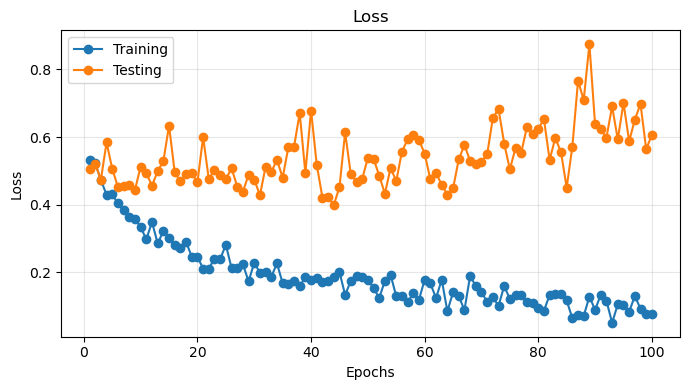

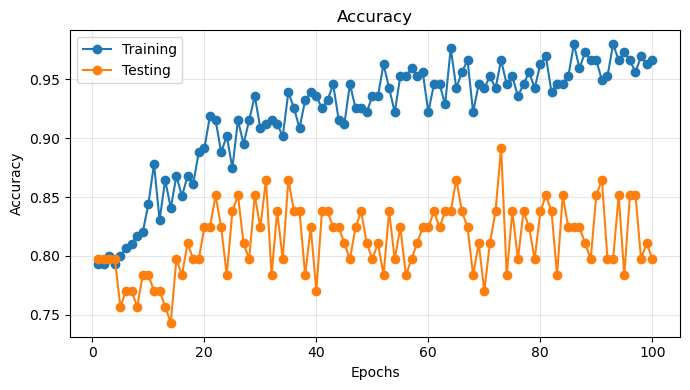

In [16]:
epochs = 100

training_loss = []
training_accuracy = []

testing_loss = []
testing_accuracy = []

for epoch in range(epochs):
	vit_model.train()

	train_total_loss = 0.0
	train_correct = 0
	train_total = 0

	train_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs} Training")
	
	for x, y in train_bar:
		x = x.to(device)
		y = y.to(device)

		optimiser.zero_grad()

		output = vit_model(x).view(-1)
		loss = criterion(output, y)
		loss.backward()
		optimiser.step()

		train_total_loss += loss.item()

		p = torch.sigmoid(output)
		vit_preds = (p >= 0.5).float()

		train_correct += (vit_preds == y).sum().item()
		train_total += y.size(0)

		accuracy = train_correct / train_total

		train_bar.set_postfix(
			accuracy=f"{accuracy:.4f}",
			loss=f"{loss.item():.4f}"
		)

	epoch_loss = train_total_loss / len(train_loader)
	epoch_accuracy = train_correct / train_total

	training_loss.append(epoch_loss)
	training_accuracy.append(epoch_accuracy)

	vit_model.eval()
 
	vit_true = []
	vit_pred = []
	vit_prob = []
	

	test_total_loss = 0.0
	test_correct = 0
	test_total = 0

	with torch.no_grad():

		test_bar = tqdm(test_loader, desc=f"Epoch {epoch + 1}/{epochs} Testing")

		for x, y in test_bar:
			x = x.to(device)
			y = y.to(device)

			logits = vit_model(x).view(-1)
			loss = criterion(logits, y)

			p = torch.sigmoid(logits)
			vit_preds = (p >= 0.5).float()

			test_total_loss += loss.item()
			test_correct += (vit_preds == y).sum().item()
			test_total += y.size(0)

			accuracy = test_correct / test_total

			test_bar.set_postfix(
				accuracy=f"{accuracy:.4f}",
				loss=f"{loss.item():.4f}"
			)

			vit_true.extend(y.cpu().numpy())
			vit_prob.extend(p.cpu().numpy())
			vit_pred.extend(vit_preds.cpu().numpy())

	epoch_test_loss = test_total_loss / len(test_loader)
	epoch_test_accuracy = test_correct / test_total if test_total > 0 else 0.0

	testing_loss.append(epoch_test_loss)
	testing_accuracy.append(epoch_test_accuracy)

	print(f"Epoch {epoch + 1}/{epochs} - "
		f"Train Accuracy: {epoch_accuracy:.4f} - "
		f"Train Loss: {epoch_loss:.4f} - "
		f"Test Accuracy: {epoch_test_accuracy:.4f} - "
		f"Test Loss: {epoch_test_loss:.4f}")
  
torch.save(vit_model.state_dict(),"Results/Models/ViT.pth")
print("Model saved: ViT")

plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), training_loss, marker="o", label="Training")
plt.plot(range(1, epochs + 1), testing_loss, marker="o", label="Testing")
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(
        "Results/Figures/ViT",
        "Loss.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()
    
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), training_accuracy, marker="o", label="Training")
plt.plot(range(1, epochs + 1), testing_accuracy, marker="o", label="Testing")
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(
        "Results/Figures/ViT",
        "Accuracy.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Accuracy: 0.7973
Precision: 0.8929
Recall: 0.8475
F1 Score: 0.8696
Specificity: 0.6000
ROC AUC: 0.8768
AUC: 0.8768

Confusion Matrix
[[ 9  6]
 [ 9 50]]

Classification Report
              precision    recall  f1-score   support

         LGG       0.50      0.60      0.55        15
         HGG       0.89      0.85      0.87        59

    accuracy                           0.80        74
   macro avg       0.70      0.72      0.71        74
weighted avg       0.81      0.80      0.80        74



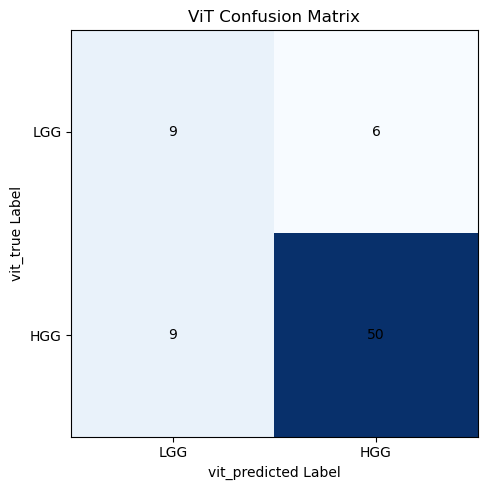

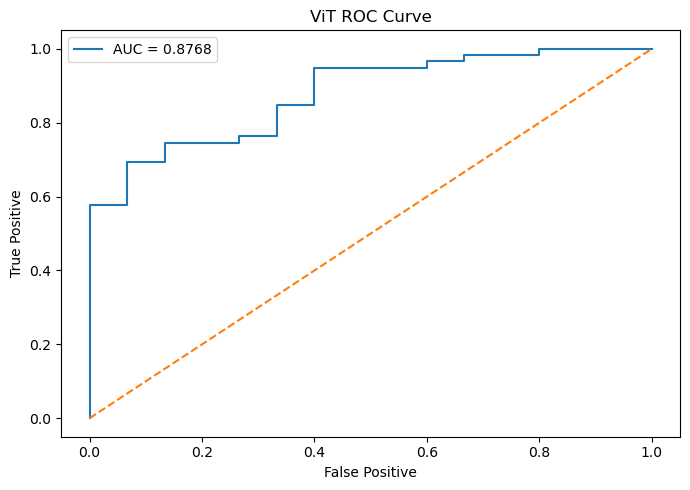

In [17]:
vit_cm = confusion_matrix(vit_true, vit_pred, labels=[0, 1])

TN, FP, FN, TP = vit_cm.ravel()

specificity = TN / (TN + FP) 

vit_metrics = {
"Accuracy": accuracy_score(vit_true, vit_pred),
"Precision": precision_score(vit_true, vit_pred, zero_division=0),
	"Recall": recall_score(vit_true, vit_pred, zero_division=0),
	"F1 Score": f1_score(vit_true, vit_pred, zero_division=0),
	"Specificity": specificity,
	"ROC AUC": roc_auc_score(vit_true, vit_prob)
}

if len(np.unique(vit_true)) == 2:
	vit_metrics["AUC"] = roc_auc_score(vit_true, vit_prob)
	
else:
	vit_metrics["AUC"] =np.nan

for name, value in vit_metrics.items():
	
	print(f"{name}: {value:.4f}")
	
print("\nConfusion Matrix")

print(vit_cm)


print("\nClassification Report")


print(classification_report(vit_true, vit_pred, labels=[0, 1], target_names=["LGG", "HGG"], zero_division=0))

plt.figure(figsize=(6, 5))
plt.imshow(vit_cm, cmap = "Blues")
plt.title("ViT Confusion Matrix")
plt.xlabel("vit_predicted Label")
plt.ylabel("vit_true Label")
plt.xticks([0, 1],["LGG", "HGG"])
plt.yticks([0, 1],["LGG", "HGG"])
for i in range(vit_cm.shape[0]):
	
	for j in range(vit_cm.shape[1]):
		plt.text(
			j,
			i,
			vit_cm[i, j],
			ha="center",
			va="center"
		)

plt.tight_layout()

plt.savefig(
	os.path.join("Results/Figures/ViT", "Confusion_Matrix.png"), dpi=300, bbox_inches="tight")

plt.show()

fpr, tpr, thresholds = roc_curve(vit_true, vit_prob)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"AUC = {vit_metrics['ROC AUC']:.4f}")

plt.plot( [0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive")

plt.ylabel("True Positive")

plt.title("ViT ROC Curve")

plt.legend()

plt.tight_layout()

plt.savefig(os.path.join("Results/Figures/ViT", "ROC_Curve.png"), dpi = 300, bbox_inches="tight")

plt.show()

vit_evaluation = pd.DataFrame({"True": vit_true, "Prediction": vit_pred, "Probability": vit_prob})

vit_evaluation.to_csv("Results/Metrics/ViT_evaluation.csv", index=False)

pd.DataFrame(vit_cm, index = ["LGG", "HGG"], columns = ["LGG", "HGG"]).to_csv("Results/Metrics/ViT_confusion_matrix.csv", index=False)

pd.DataFrame([vit_metrics]).to_csv("Results/Metrics/ViT_metrics.csv", index=False)

In [18]:
class EfficientNet(nn.Module):
    def __init__(self, in_channels=4):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv3d(
                in_channels,
                24,
                kernel_size=(3, 3, 3),
                stride=(2, 2, 2),
                padding=(1, 1, 1),
                bias=False,
            ),
            nn.BatchNorm3d(24),
            nn.SiLU(),
        )

        configurations = [
            (24, 24, 1, 1),
            (24, 32, 2, 4),
            (32, 32, 1, 4),
            (32, 48, 2, 4),
            (48, 48, 1, 4),
            (48, 80, 2, 4),
            (80, 80, 1, 4),
            (80, 128, 2, 4),
            (128, 128, 1, 4),
        ]

        self.blocks = nn.ModuleList()
        self.residual = []

        for in_channels, out_channels, stride, expansion in configurations:
            hidden_channels = in_channels * expansion
            reduced_channels = max(1, hidden_channels // 4)

            expand = nn.Sequential(
                nn.Conv3d(
                    in_channels,
                    hidden_channels,
                    kernel_size=1,
                    bias=False,
                ),
                nn.BatchNorm3d(hidden_channels),
                nn.SiLU(),
            )

            depthwise = nn.Sequential(
                nn.Conv3d(
                    hidden_channels,
                    hidden_channels,
                    kernel_size=3,
                    stride=stride,
                    padding=1,
                    groups=hidden_channels,
                    bias=False,
                ),
                nn.BatchNorm3d(hidden_channels),
                nn.SiLU(),
            )

            squeeze_excitation = nn.Sequential(
                nn.AdaptiveAvgPool3d(1),
                nn.Conv3d(
                    hidden_channels,
                    reduced_channels,
                    kernel_size=1,
                ),
                nn.SiLU(),
                nn.Conv3d(
                    reduced_channels,
                    hidden_channels,
                    kernel_size=1,
                ),
                nn.Sigmoid(),
            )

            project = nn.Sequential(
                nn.Conv3d(
                    hidden_channels,
                    out_channels,
                    kernel_size=1,
                    bias=False,
                ),
                nn.BatchNorm3d(out_channels),
            )

            block = nn.ModuleDict(
                {
                    "expand": expand,
                    "depthwise": depthwise,
                    "squeeze_excitation": squeeze_excitation,
                    "project": project,
                }
            )

            self.blocks.append(block)

            self.residual.append(
                stride == 1
                and in_channels == out_channels
            )

        self.dropout = nn.Dropout3d(0.1)

        self.head = nn.Sequential(
            nn.Conv3d(
                128,
                192,
                kernel_size=1,
                bias=False,
            ),
            nn.BatchNorm3d(192),
            nn.SiLU(),
            nn.AdaptiveAvgPool3d(1),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(192, 1),
        )

    def forward(self, x):
        x = self.stem(x)

        for block, use_residual in zip(
            self.blocks,
            self.residual
        ):
            identity = x

            x = block["expand"](x)
            x = block["depthwise"](x)

            scale = block["squeeze_excitation"](x)
            x = scale * x

            x = block["project"](x)

            if use_residual:
                x = self.dropout(x) + identity

        x = self.head(x)
        x = self.classifier(x)

        return x

In [19]:
eff_model = EfficientNet(in_channels=4)

eff_model = eff_model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimiser = torch.optim.AdamW(eff_model.parameters(), lr = 1.5e-4, weight_decay = 1e-5)

print(eff_model.__class__.__name__)


EfficientNet


Epoch 1/100 Testing: 100%|██████████| 19/19 [01:03<00:00,  3.36s/it, accuracy=0.7973, loss=0.5368]


Epoch 1/100 - Train Accuracy: 0.6746 - Train Loss: 0.6512 - Test Accuracy: 0.7973 - Test Loss: 0.6157


Epoch 2/100 Testing: 100%|██████████| 19/19 [00:59<00:00,  3.11s/it, accuracy=0.7973, loss=0.5689]


Epoch 2/100 - Train Accuracy: 0.7458 - Train Loss: 0.5721 - Test Accuracy: 0.7973 - Test Loss: 0.5605


Epoch 3/100 Testing: 100%|██████████| 19/19 [00:58<00:00,  3.08s/it, accuracy=0.7838, loss=0.5079]


...

Epoch 98/100 - Train Accuracy: 0.9898 - Train Loss: 0.0267 - Test Accuracy: 0.8784 - Test Loss: 0.4164


Epoch 99/100 Testing: 100%|██████████| 19/19 [01:00<00:00,  3.19s/it, accuracy=0.8514, loss=0.6710]


Epoch 99/100 - Train Accuracy: 0.9898 - Train Loss: 0.0411 - Test Accuracy: 0.8514 - Test Loss: 0.4678


Epoch 100/100 Testing: 100%|██████████| 19/19 [00:59<00:00,  3.11s/it, accuracy=0.8243, loss=1.1390]


Epoch 100/100 - Train Accuracy: 0.9797 - Train Loss: 0.1139 - Test Accuracy: 0.8243 - Test Loss: 0.5570
Model saved: EfficientNet


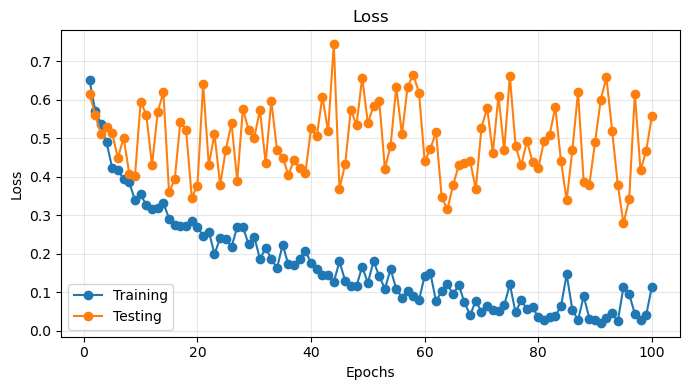

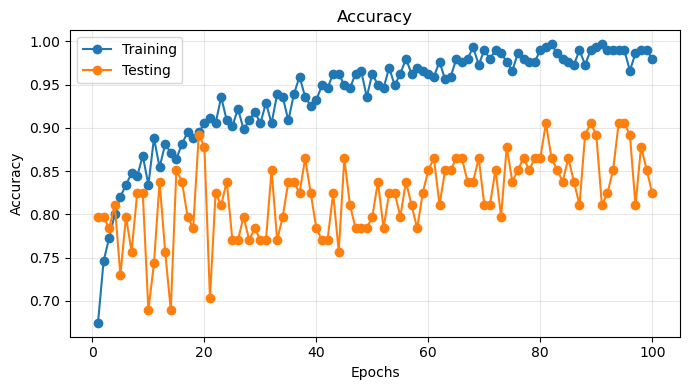

In [20]:
epochs = 100

training_loss = []
training_accuracy = []

testing_loss = []
testing_accuracy = []

for epoch in range(epochs):
	eff_model.train()

	train_total_loss = 0.0
	train_correct = 0
	train_total = 0

	train_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs} Training")
	
	for x, y in train_bar:
		x = x.to(device)
		y = y.to(device)

		optimiser.zero_grad()

		output = eff_model(x).view(-1)
		loss = criterion(output, y)
		loss.backward()
		optimiser.step()

		train_total_loss += loss.item()

		p = torch.sigmoid(output)
		eff_preds = (p >= 0.5).float()

		train_correct += (eff_preds == y).sum().item()
		train_total += y.size(0)

		accuracy = train_correct / train_total

		train_bar.set_postfix(
			accuracy=f"{accuracy:.4f}",
			loss=f"{loss.item():.4f}"
		)

	epoch_loss = train_total_loss / len(train_loader)
	epoch_accuracy = train_correct / train_total

	training_loss.append(epoch_loss)
	training_accuracy.append(epoch_accuracy)

	eff_model.eval()
	
	eff_true = []
	eff_pred = []
	eff_prob = []

	test_total_loss = 0.0
	test_correct = 0
	test_total = 0

	with torch.no_grad():

		test_bar = tqdm(test_loader, desc=f"Epoch {epoch + 1}/{epochs} Testing")

		for x, y in test_bar:
			x = x.to(device)
			y = y.to(device)

			logits = eff_model(x).view(-1)
			loss = criterion(logits, y)

			p = torch.sigmoid(logits)
			eff_preds = (p >= 0.5).float()

			test_total_loss += loss.item()
			test_correct += (eff_preds == y).sum().item()
			test_total += y.size(0)

			accuracy = test_correct / test_total

			test_bar.set_postfix(
				accuracy=f"{accuracy:.4f}",
				loss=f"{loss.item():.4f}"
			)

			eff_true.extend(y.cpu().numpy())
			eff_prob.extend(p.cpu().numpy())
			eff_pred.extend(eff_preds.cpu().numpy())

	epoch_test_loss = test_total_loss / len(test_loader)
	epoch_test_accuracy = test_correct / test_total if test_total > 0 else 0.0

	testing_loss.append(epoch_test_loss)
	testing_accuracy.append(epoch_test_accuracy)

	print(f"Epoch {epoch + 1}/{epochs} - "
		f"Train Accuracy: {epoch_accuracy:.4f} - "
		f"Train Loss: {epoch_loss:.4f} - "
		f"Test Accuracy: {epoch_test_accuracy:.4f} - "
		f"Test Loss: {epoch_test_loss:.4f}")
  
torch.save(eff_model.state_dict(),"Results/Models/EfficientNet.pth")
print("Model saved: EfficientNet")

plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), training_loss, marker="o", label="Training")
plt.plot(range(1, epochs + 1), testing_loss, marker="o", label="Testing")
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(
        "Results/Figures/EfficientNet",
        "Loss.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()
    
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), training_accuracy, marker="o", label="Training")
plt.plot(range(1, epochs + 1), testing_accuracy, marker="o", label="Testing")
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
os.path.join("Results/Figures/EfficientNet","Accuracy.png"), dpi = 300, bbox_inches="tight")
plt.show()

Accuracy: 0.8243
Precision: 0.9259
Recall: 0.8475
F1 Score: 0.8850
Specificity: 0.7333
ROC AUC: 0.8938
AUC: 0.8938

Confusion Matrix
[[11  4]
 [ 9 50]]

Classification Report
              precision    recall  f1-score   support

         LGG       0.55      0.73      0.63        15
         HGG       0.93      0.85      0.88        59

    accuracy                           0.82        74
   macro avg       0.74      0.79      0.76        74
weighted avg       0.85      0.82      0.83        74



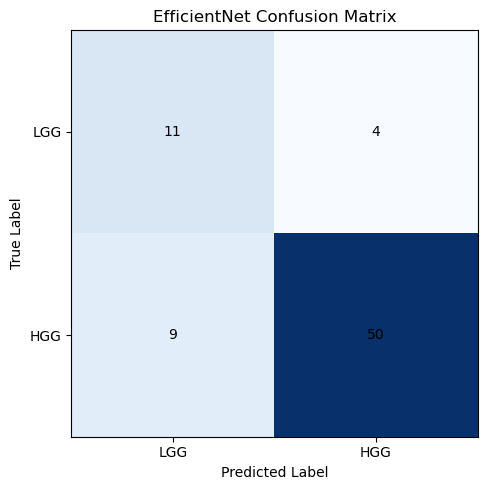

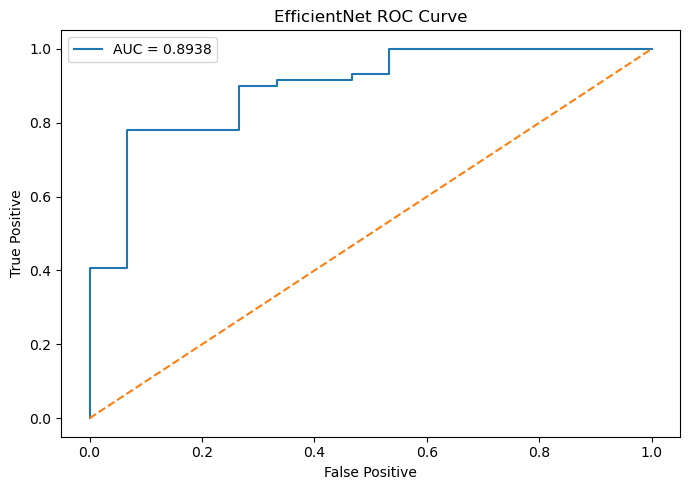

In [21]:
eff_cm = confusion_matrix(eff_true, eff_pred, labels=[0, 1])

TN, FP, FN, TP = eff_cm.ravel()

specificity = TN / (TN + FP) 

eff_metrics = {
"Accuracy": accuracy_score(eff_true, eff_pred),
"Precision": precision_score(eff_true, eff_pred, zero_division=0),
	"Recall": recall_score(eff_true, eff_pred, zero_division=0),
	"F1 Score": f1_score(eff_true, eff_pred, zero_division=0),
	"Specificity": specificity,
	"ROC AUC": roc_auc_score(eff_true, eff_prob)
}

if len(np.unique(eff_true)) == 2:
	eff_metrics["AUC"] = roc_auc_score(eff_true, eff_prob)
	
else:
	eff_metrics["AUC"] =np.nan

for name, value in eff_metrics.items():
	
	print(f"{name}: {value:.4f}")
	
print("\nConfusion Matrix")

print(eff_cm)


print("\nClassification Report")


print(classification_report(eff_true, eff_pred, labels=[0, 1], target_names=["LGG", "HGG"], zero_division=0))

plt.figure(figsize=(6, 5))
plt.imshow(eff_cm, cmap = "Blues")
plt.title("EfficientNet Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1],["LGG", "HGG"])
plt.yticks([0, 1],["LGG", "HGG"])
for i in range(eff_cm.shape[0]):
	
	for j in range(eff_cm.shape[1]):
		plt.text(
			j,
			i,
			eff_cm[i, j],
			ha="center",
			va="center"
		)

plt.tight_layout()

plt.savefig(
	os.path.join(
		"Results/Figures/EfficientNet",
		"Confusion_Matrix.png"
	),
	dpi=300,
	bbox_inches="tight"
)

plt.show()

fpr, tpr, thresholds = roc_curve(eff_true, eff_prob)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"AUC = {eff_metrics['ROC AUC']:.4f}")

plt.plot( [0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive")

plt.ylabel("True Positive")

plt.title("EfficientNet ROC Curve")

plt.legend()

plt.tight_layout()

plt.savefig(os.path.join("Results/Figures/EfficientNet", "ROC_Curve.png"), dpi=300, bbox_inches="tight")

plt.show()

pd.DataFrame([eff_metrics]).to_csv("Results/Metrics/EfficientNet_metrics.csv",index=False)

eff_evaluation = pd.DataFrame({"True": eff_true, "Prediction": eff_pred, "Probability": eff_prob})

eff_evaluation.to_csv("Results/Metrics/EfficientNet_evaluation.csv", index=False)

pd.DataFrame(eff_cm, index = ["LGG", "HGG"], columns = ["LGG", "HGG"]).to_csv("Results/Metrics/EfficientNet_confusion_matrix.csv")

In [ ]:
vit_model.load_state_dict(
torch.load("Results/Models/ViT.pth"
,map_location = device)
)

vit_model = vit_model.to(device)
vit_model.eval()
for module in vit_model.modules():
	if isinstance(module, (nn.Dropout, nn.Dropout2d, nn.Dropout3d)):
		module.train()
		
mc_samples = 74

vit_mc_true = []
vit_mc_pred = []
vit_mc_prob = []
vit_mc_uncertainty = []

with torch.no_grad():
	
	test_bar = tqdm(test_loader, desc = "MC Dropout Testing")
	for x, y in test_bar:
		x = x.to(device)
		y = y.to(device)
		probabilities = []
		
		for sample in range(mc_samples):
			
			logits = vit_model(x).view(-1)
			
			p = torch.sigmoid(logits)
			
			probabilities.append(p)
			
		probabilities = torch.stack(probabilities)
		
		mean_probability = probabilities.mean(dim = 0)
		
		uncertainty = probabilities.std(dim = 0)
		
		predictions = (mean_probability >= 0.5).float()
		
		vit_mc_true.extend(y.cpu().numpy().tolist())
		
		vit_mc_pred.extend(predictions.cpu().numpy().tolist())
		
		vit_mc_prob.extend(mean_probability.cpu().numpy().tolist())
		
		vit_mc_uncertainty.extend(uncertainty.cpu().numpy().tolist())
		
		
	vit_mc_true = np.asarray(vit_mc_true)
	
	vit_mc_pred = np.asarray(vit_mc_pred)
	
	vit_mc_prob = np.asarray(vit_mc_prob)
	
	vit_mc_uncertainty = np.asarray(vit_mc_uncertainty)
	
	vit_mc_cm = confusion_matrix(vit_mc_true, vit_mc_pred, labels=[0, 1])
	
	TN, FP, FN, TP = vit_mc_cm.ravel()
	
	specificity = TN / (TN + FP) 
	
	vit_mc_metrics = {
		"Accuracy": accuracy_score(vit_mc_true, vit_mc_pred),
		"Precision": precision_score(vit_mc_true, vit_mc_pred, zero_division=0),
		"Recall": recall_score(vit_mc_true, vit_mc_pred, zero_division=0),
		"F1 Score": f1_score(vit_mc_true, vit_mc_pred, zero_division=0),
		"Specificity": specificity,
		"ROC AUC": roc_auc_score(vit_mc_true, vit_mc_prob),
		"Mean Uncertainty": vit_mc_uncertainty.mean()
		}
	
		
vit_mc_true = np.asarray(vit_mc_true)
vit_mc_pred = np.asarray(vit_mc_pred)
vit_mc_prob = np.asarray(vit_mc_prob)
vit_mc_uncertainty = np.asarray(vit_mc_uncertainty)

accuracy = accuracy_score(vit_mc_true, vit_mc_pred)
precision = precision_score(vit_mc_true, vit_mc_pred)
recall = recall_score(vit_mc_true, vit_mc_pred)
f1 = f1_score(vit_mc_true, vit_mc_pred)
TN, FP, FN, TP = confusion_matrix(vit_mc_true, vit_mc_pred).ravel()
specificity = TN / (TN + FP) 

print("MC Dropout Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Specificity:", specificity)
print("F1 Score:", f1)
print("Mean Uncertainty:", vit_mc_uncertainty.mean())
print("\nConfusion Matrix")
print(
	confusion_matrix(
		vit_mc_true,
		vit_mc_pred
	)
)

print("\nClassification Report")
print(
	classification_report(
		vit_mc_true,
		vit_mc_pred,
		target_names=["LGG", "HGG"]
	)
)

MC Dropout Testing: 100%|██████████| 19/19 [01:18<00:00,  4.14s/it]

MC Dropout Results
Accuracy: 0.7972972972972973
Precision: 0.8928571428571429
Recall: 0.847457627118644
Specificity: 0.6
F1 Score: 0.8695652173913043
Mean Uncertainty: 0.0821637800637856

Confusion Matrix
[[ 9  6]
 [ 9 50]]

Classification Report
              precision    recall  f1-score   support

         LGG       0.50      0.60      0.55        15
         HGG       0.89      0.85      0.87        59

    accuracy                           0.80        74
   macro avg       0.70      0.72      0.71        74
weighted avg       0.81      0.80      0.80        74



In [23]:
vit_mc_result = pd.DataFrame({
	"patient": test_df["patient"],
	"True": vit_mc_true,
	"Prediction": vit_mc_pred,
	"Probability": vit_mc_prob,
	"Uncertainty": vit_mc_uncertainty
})

vit_mc_result.to_csv("Results/MC_Metrics/ViT_MC_Dropout.csv", index=False)

pd.DataFrame([vit_mc_metrics]).to_csv("Results/MC_Metrics/ViT_MC_Dropout_metrics.csv", index = False)

pd.DataFrame(vit_mc_cm, index = ["LGG", "HGG"], columns = ["LGG", "HGG"]).to_csv("Results/MC_Metrics/ViT_MC_Dropout_confusion_matrix.csv")

print("ViT MC Dropout results saved")

vit_highest_uncertainty = np.argmax(vit_mc_uncertainty)

print("ViT highest uncertainty patient: ", test_df.iloc[vit_highest_uncertainty]["patient"])
print("ViT uncertainty patient: ", vit_mc_uncertainty[vit_highest_uncertainty])

ViT MC Dropout results saved
ViT highest uncertainty patient:  BraTS20_Training_237
ViT uncertainty patient:  0.30681926012039185


In [ ]:
eff_model.load_state_dict(
torch.load("Results/Models/EfficientNet.pth"
,map_location = device)
)

eff_model = eff_model.to(device)

eff_model.eval()
for module in eff_model.modules():
	if isinstance(module, (nn.Dropout, nn.Dropout2d, nn.Dropout3d)):
		module.train()
		
mc_samples = 74

eff_mc_true = []
eff_mc_pred = []
eff_mc_prob = []
eff_mc_uncertainty = []

with torch.no_grad():
	
	test_bar = tqdm(test_loader, desc = "MC Dropout Testing")
	for x, y in test_bar:
		x = x.to(device)
		y = y.to(device)
		probabilities = []
		
		for sample in range(mc_samples):
			
			logits = eff_model(x).view(-1)
			
			p = torch.sigmoid(logits)
			
			probabilities.append(p)
			
		probabilities = torch.stack(probabilities)
		
		mean_probability = probabilities.mean(dim = 0)
		
		uncertainty = probabilities.std(dim = 0)
		
		predictions = (mean_probability >= 0.5).float()
		
		eff_mc_true.extend(y.cpu().numpy().tolist())
		
		eff_mc_pred.extend(predictions.cpu().numpy().tolist())
		
		eff_mc_prob.extend(mean_probability.cpu().numpy().tolist())
		
		eff_mc_uncertainty.extend(uncertainty.cpu().numpy().tolist())
  
	eff_mc_true = np.asarray(eff_mc_true)
	
	eff_mc_pred = np.asarray(eff_mc_pred)
	
	eff_mc_prob = np.asarray(eff_mc_prob)
	
	eff_mc_uncertainty = np.asarray(eff_mc_uncertainty)
	
	eff_mc_cm = confusion_matrix(eff_mc_true, eff_mc_pred, labels=[0, 1])
	
	TN, FP, FN, TP = eff_mc_cm.ravel()
	
	specificity = TN / (TN + FP) 
	
	eff_mc_metrics = {
		"Accuracy": accuracy_score(eff_mc_true, eff_mc_pred),
		"Precision": precision_score(eff_mc_true, eff_mc_pred, zero_division=0),
		"Recall": recall_score(eff_mc_true, eff_mc_pred, zero_division=0),
		"F1 Score": f1_score(eff_mc_true, eff_mc_pred, zero_division=0),
		"Specificity": specificity,
		"ROC AUC": roc_auc_score(eff_mc_true, eff_mc_prob),
		"Mean Uncertainty": eff_mc_uncertainty.mean()
		}
	
		
eff_mc_true = np.asarray(eff_mc_true)
eff_mc_pred = np.asarray(eff_mc_pred)
eff_mc_prob = np.asarray(eff_mc_prob)
eff_mc_uncertainty = np.asarray(eff_mc_uncertainty)

accuracy = accuracy_score(eff_mc_true, eff_mc_pred)
precision = precision_score(eff_mc_true, eff_mc_pred)
recall = recall_score(eff_mc_true, eff_mc_pred)
f1 = f1_score(eff_mc_true, eff_mc_pred)
TN, FP, FN, TP = confusion_matrix(eff_mc_true, eff_mc_pred).ravel()
specificity = TN / (TN + FP) 

print("MC Dropout Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Specificity:", specificity)
print("F1 Score:", f1)
print("Mean Uncertainty:", eff_mc_uncertainty.mean())
print("\nConfusion Matrix")
print(
	confusion_matrix(
		eff_mc_true,
		eff_mc_pred
	)
)

print("\nClassification Report")
print(
	classification_report(
		eff_mc_true,
		eff_mc_pred,
		target_names=["LGG", "HGG"]
	)
)

MC Dropout Testing: 100%|██████████| 19/19 [17:45<00:00, 56.06s/it]

MC Dropout Results
Accuracy: 0.8378378378378378
Precision: 0.9272727272727272
Recall: 0.864406779661017
Specificity: 0.7333333333333333
F1 Score: 0.8947368421052632
Mean Uncertainty: 0.053128010307806395

Confusion Matrix
[[11  4]
 [ 8 51]]

Classification Report
              precision    recall  f1-score   support

         LGG       0.58      0.73      0.65        15
         HGG       0.93      0.86      0.89        59

    accuracy                           0.84        74
   macro avg       0.75      0.80      0.77        74
weighted avg       0.86      0.84      0.84        74



In [25]:
eff_mc_result = pd.DataFrame({
	"patient": test_df["patient"],
	"True": eff_mc_true,
	"Prediction": eff_mc_pred,
	"Probability": eff_mc_prob,
	"Uncertainty": eff_mc_uncertainty
})

eff_mc_result.to_csv(
	"Results/MC_Metrics/EfficientNet_MC_Dropout.csv",
	index=False
)

pd.DataFrame(
	[eff_mc_metrics]
).to_csv(
	"Results/MC_Metrics/EfficientNet_MC_Dropout_metrics.csv",
	index=False
)

pd.DataFrame(
	eff_mc_cm,
	index=["LGG", "HGG"],
	columns=["LGG", "HGG"]
).to_csv(
	"Results/MC_Metrics/EfficientNet_MC_Dropout_confusion_matrix.csv"
)

print("EfficientNet MC Dropout results saved")

eff_highest_uncertainty = np.argmax(eff_mc_uncertainty)

print("EfficientNet highest uncertainty patient: ", test_df.iloc[eff_highest_uncertainty]["patient"])
print("EfficientNet uncertainty patient: ", eff_mc_uncertainty[eff_highest_uncertainty],"\n")

EfficientNet MC Dropout results saved
EfficientNet highest uncertainty patient:  BraTS20_Training_312
EfficientNet uncertainty patient:  0.28222399950027466 



In [26]:
mc_comparison = pd.DataFrame([vit_mc_metrics, eff_mc_metrics])

mc_comparison.to_csv("Results/MC_Metrics/MC_Dropout_Model_Comparison.csv", index = False)

mc_comparison

,Accuracy,Precision,Recall,F1 Score,Specificity,ROC AUC,Mean Uncertainty
0,0.797297,0.892857,0.847458,0.869565,0.600000,0.879096,0.082164
1,0.837838,0.927273,0.864407,0.894737,0.733333,0.897175,0.053128


In [27]:
uncertainty_result = pd.DataFrame ({
    "patient": test_df["patient"],
    "True labels":vit_mc_true,
    "ViT Prediction":vit_mc_pred, 
    "ViT Probability":vit_mc_prob,
    "ViT Uncertainty":vit_mc_uncertainty,
    "EfficientNet Prediction":eff_mc_pred, 
    "EfficientNet Probability":eff_mc_prob, 
    "EfficientNet Uncertainty":eff_mc_uncertainty
})

uncertainty_result.to_csv("Results/MC_Metrics/Patient_Uncertainty.csv", index=False)

uncertainty_result

,patient,True labels,ViT Prediction,ViT Probability,ViT Uncertainty,EfficientNet Prediction,EfficientNet Probability,EfficientNet Uncertainty
0,BraTS20_Training_227,1.0,0.0,0.392433,0.280650,0.0,0.067067,0.072813
1,BraTS20_Training_297,0.0,0.0,0.068462,0.098559,0.0,0.004496,0.002235
2,BraTS20_Training_188,1.0,0.0,0.397994,0.242889,0.0,0.053959,0.032667
3,BraTS20_Training_320,0.0,1.0,0.939140,0.076726,1.0,0.991679,0.013661
4,BraTS20_Training_101,1.0,1.0,0.999208,0.000150,1.0,0.996851,0.006855
...,...,...,...,...,...,...,...,...
69,BraTS20_Training_281,0.0,0.0,0.039285,0.056101,0.0,0.137397,0.109816
70,BraTS20_Training_359,1.0,0.0,0.491063,0.293585,1.0,0.997745,0.005822
71,BraTS20_Training_205,1.0,0.0,0.336881,0.245709,0.0,0.066409,0.066946
72,BraTS20_Training_237,1.0,0.0,0.412208,0.306819,1.0,0.549281,0.236172


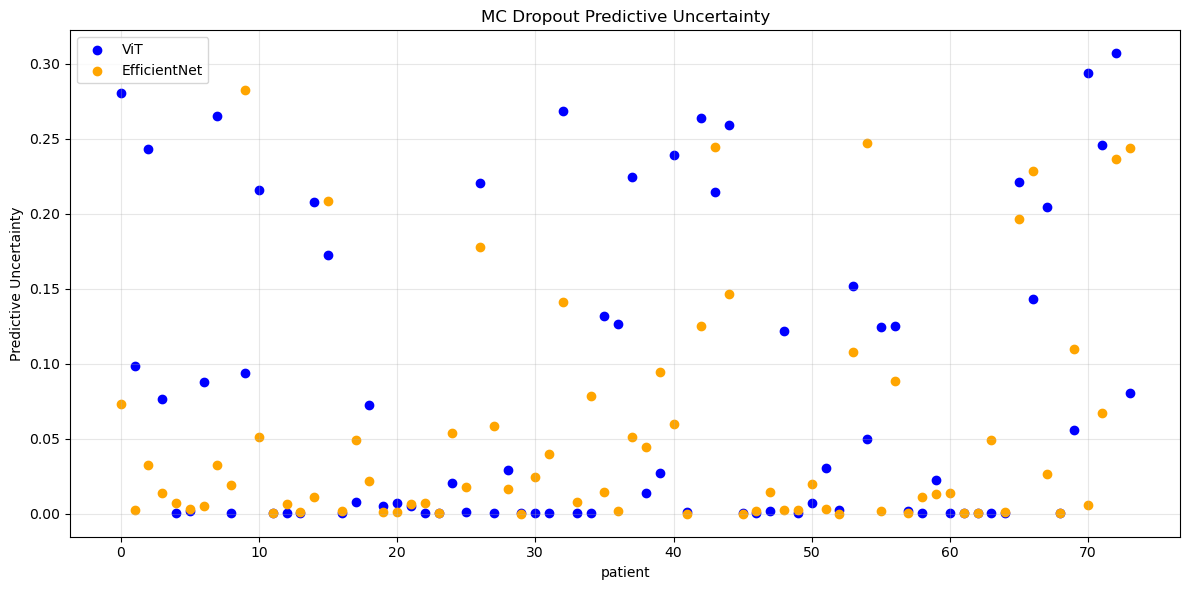

In [28]:
sample = np.arange(len(vit_mc_true))

plt.figure(figsize = (12, 6))

plt.scatter(sample, vit_mc_uncertainty, color = "blue", label = "ViT")

plt.scatter(sample, eff_mc_uncertainty, color = "orange", label = "EfficientNet")

plt.xlabel("patient")

plt.ylabel("Predictive Uncertainty")

plt.title("MC Dropout Predictive Uncertainty")

plt.legend()

plt.grid(alpha = 0.3)

plt.tight_layout()

plt.savefig("Results/Figures/Comparison/MC_Dropout_Uncertainty.png", dpi=300, bbox_inches="tight")

plt.show()

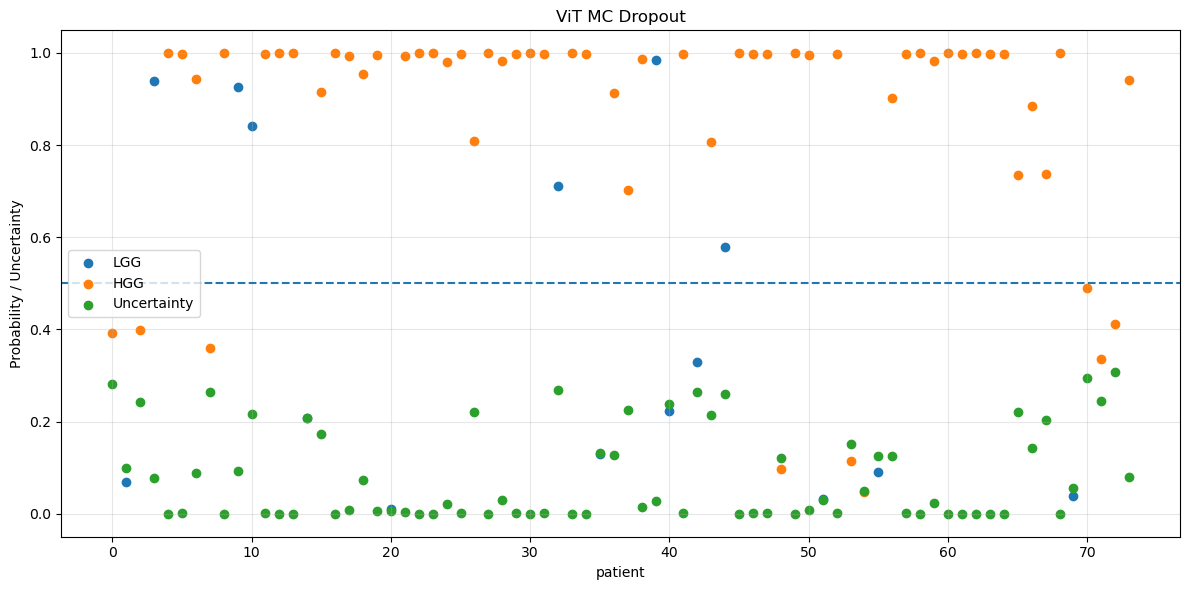

In [29]:
sample = np.arange(len(vit_mc_true))

LGG = vit_mc_true == 0
HGG = vit_mc_true == 1

plt.figure(figsize = (12, 6))

plt.scatter(sample[LGG], vit_mc_prob[LGG], label = "LGG")

plt.scatter(sample[HGG], vit_mc_prob[HGG], label = "HGG")

plt.scatter(sample, vit_mc_uncertainty, label = "Uncertainty")

plt.axhline(y=0.5, linestyle="--")

plt.xlabel("patient")

plt.ylabel("Probability / Uncertainty")

plt.title("ViT MC Dropout")

plt.legend()

plt.grid(alpha = 0.3)

plt.tight_layout()

plt.savefig("Results/Figures/ViT/MC_Dropout.png", dpi=300, bbox_inches="tight")

plt.show()

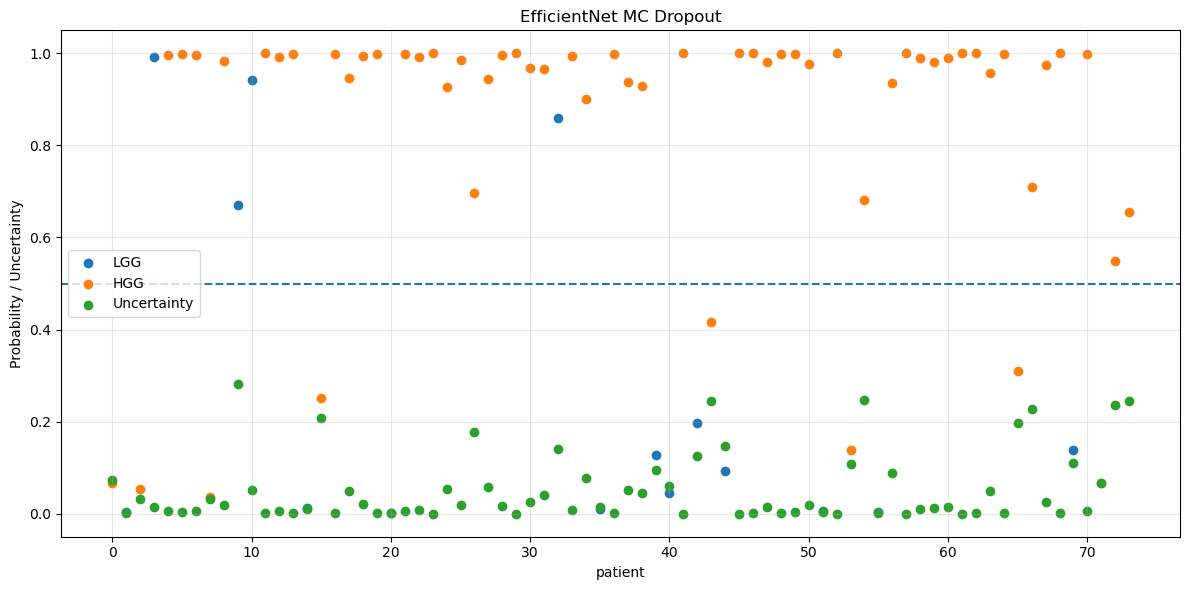

In [30]:
sample = np.arange(len(eff_mc_true))

LGG = eff_mc_true == 0
HGG = eff_mc_true == 1

plt.figure(figsize = (12, 6))

plt.scatter(sample[LGG], eff_mc_prob[LGG], label = "LGG")

plt.scatter(sample[HGG], eff_mc_prob[HGG], label = "HGG")

plt.scatter(sample, eff_mc_uncertainty, label = "Uncertainty")


plt.axhline(y=0.5, linestyle="--")

plt.xlabel("patient")

plt.ylabel("Probability / Uncertainty")

plt.title("EfficientNet MC Dropout")

plt.legend()

plt.grid(alpha = 0.3)

plt.tight_layout()

plt.savefig("Results/Figures/EfficientNet/MC_Dropout.png", dpi=300, bbox_inches="tight")

plt.show()

In [31]:
vit_model = vit_model.to(device)
vit_model.eval()

features = []

target_layer = vit_model.transformer.layers[-1][0].norm

handle = target_layer.register_forward_hook(lambda module, input, output: features.append(output))

vit_sample_indexes = [0, vit_highest_uncertainty]

vit_cams = []

vit_mris = []

vit_labels = []

vit_probabilities = []

vit_predictions = []

for vit_sample_index in vit_sample_indexes:
    
    features.clear()
    
    vit_x, vit_y = test_dataset[vit_sample_index]
    
    vit_x = vit_x.unsqueeze(0).to(device)
    
    vit_model.zero_grad()
    logits = vit_model(vit_x).view(-1)	
    vit_probability = torch.sigmoid(logits)
    
    if vit_probability.item() >= 0.5:
        score = logits[0]
    else:
        score = -logits[0]
        
    feature = features[0]
    
    feature.retain_grad()
    
    score.backward()
    
    gradient = feature.grad
    
    feature = feature[:, 1:, :]
    gradient = gradient[:, 1:, :]
    
    feature = feature.reshape(1, 6, 6, 6, feature.shape[-1])
    gradient = gradient.reshape(1, 6, 6, 6, gradient.shape[-1])
    
    feature = feature.permute(0, 4, 1, 2, 3)
    gradient = gradient.permute(0, 4, 1, 2, 3)
    
    weight = gradient.mean(dim = (2, 3, 4), keepdim = True)
    
    vit_cam = (weight * feature).sum(dim = 1, keepdim = True)
    vit_cam = F.relu(vit_cam)
    vit_cam = F.interpolate(vit_cam, size = (96, 96 ,96), mode = "trilinear", align_corners = False)
    vit_cam = vit_cam.squeeze()
    vit_cam = vit_cam / (vit_cam.max() + 1e-8)
    vit_cam = vit_cam.detach().cpu().numpy()
    
    vit_cams.append(vit_cam)
    
    vit_mris.append(vit_x[0].detach().cpu().numpy())
    
    vit_labels.append(vit_y.item())
    
    vit_probabilities.append(vit_probability.item())
    
    vit_predictions.append(int(vit_probability.item() >= 0.5))


handle.remove()

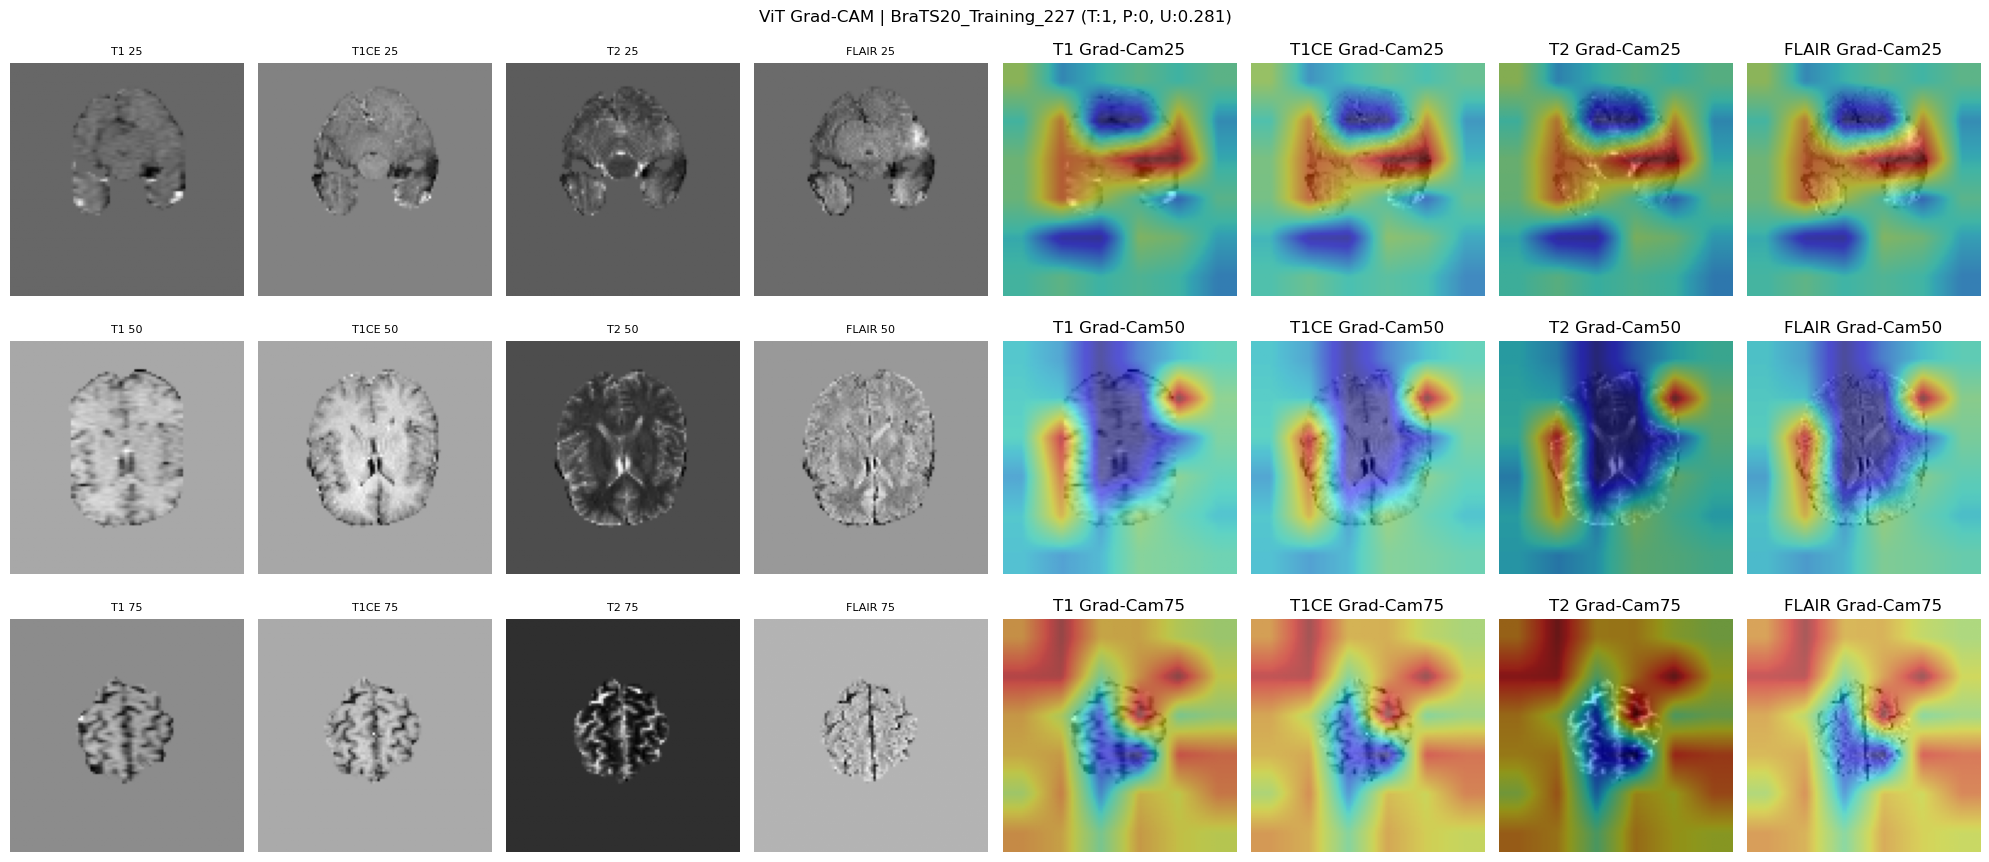

In [32]:
names = ["T1", "T1CE", "T2", "FLAIR"]

slices = [25, 50, 75]

rows = len(slices)

cols = 8

plt.figure(figsize = (20, 3 * rows))

patient = test_df.iloc[vit_sample_indexes[0]]["patient"]
    
mri = vit_mris[0]
    
cam = vit_cams[0]
    
for r, s in enumerate(slices):
		
	for c in range(4):
		
		plt.subplot(rows, cols, r * cols + c + 1)
		
		plt.imshow(mri[c, s].T, cmap = "gray", origin = "lower")
		
		plt.title(f"{names[c]} {s}", fontsize = 8)
		
		plt.axis("off")
		
		plt.subplot(rows, cols, r * cols + c + 5)
		
		plt.imshow(mri[c, s].T, cmap = "gray", origin = "lower")
		
		plt.imshow(cam[s].T, cmap = "jet", alpha = 0.5, origin = "lower")
		
		plt.title(f"{names[c]} Grad-Cam{s}")
		
		plt.axis("off")


plt.suptitle(
    f"ViT Grad-CAM | "
    f"{patient} "
    f"(T:{int(vit_labels[0])}, "
    f"P:{vit_predictions[0]}, "
    f"U:{vit_mc_uncertainty[vit_sample_indexes[0]]:.3f})"
)

plt.tight_layout()

plt.savefig(
f"Results/Figures/ViT/GradCAM/{patient}.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

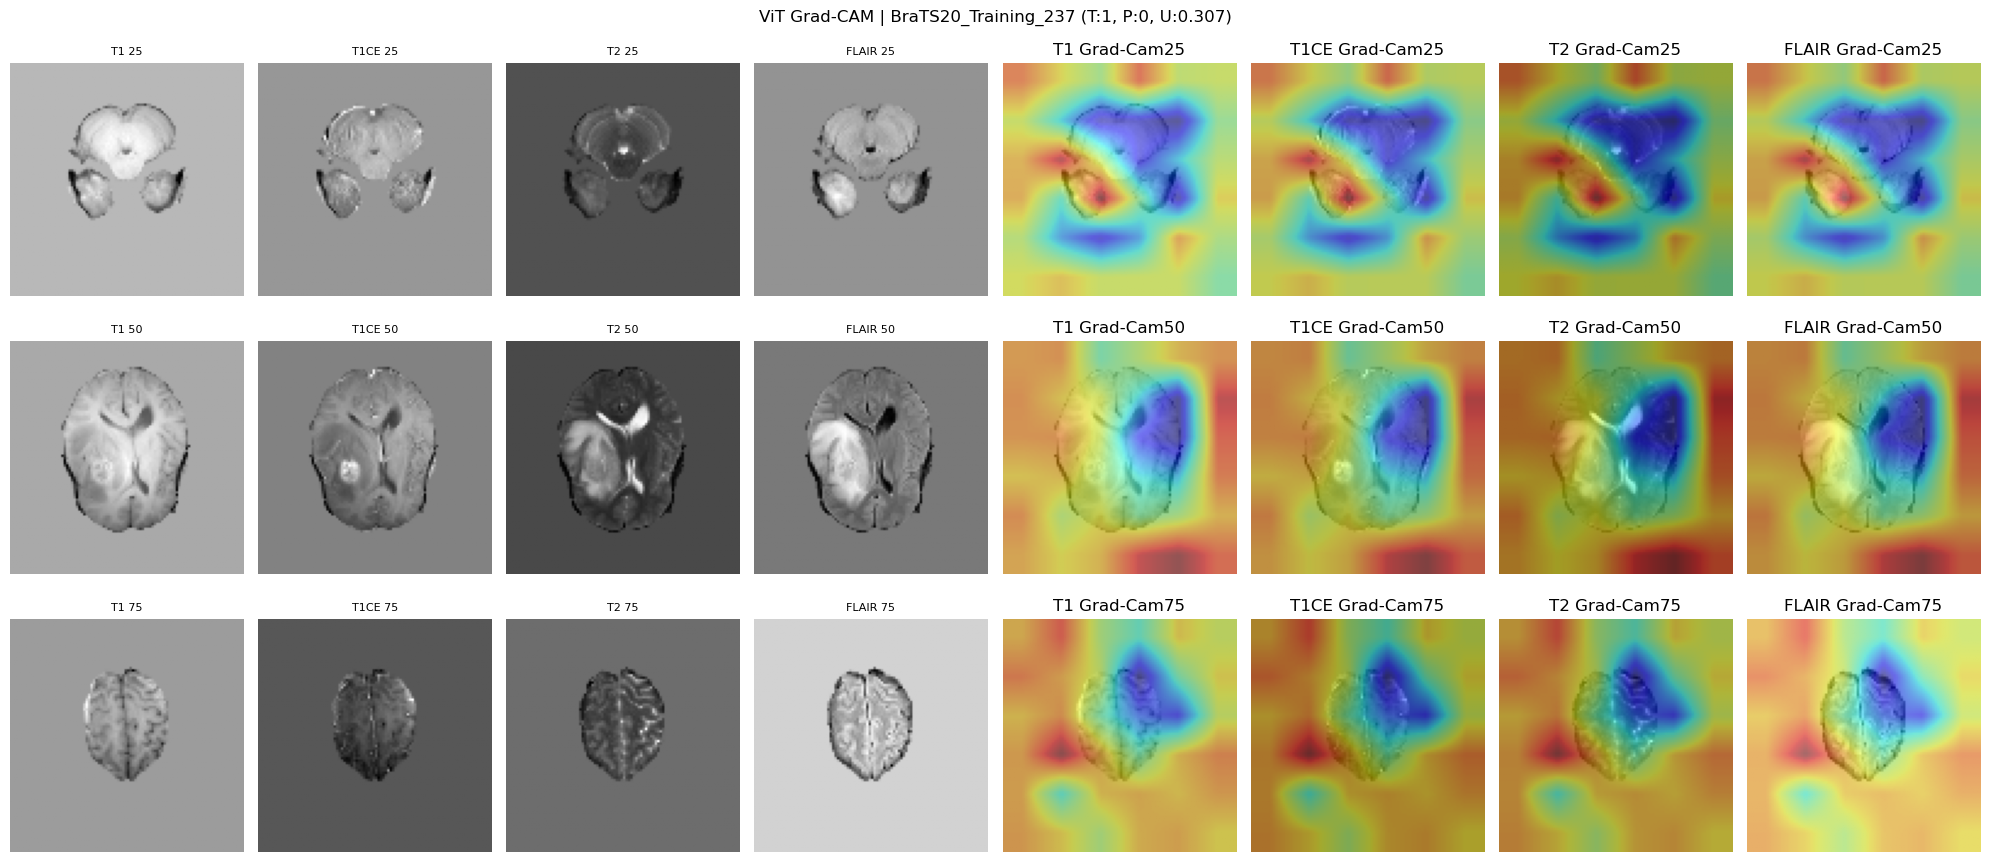

In [33]:
names = ["T1", "T1CE", "T2", "FLAIR"]

slices = [25, 50, 75]

rows = len(slices)

cols = 8

plt.figure(figsize = (20, 3 * rows))

patient = test_df.iloc[vit_sample_indexes[1]]["patient"]
    
mri = vit_mris[1]
    
cam = vit_cams[1]
    
for r, s in enumerate(slices):
		
	for c in range(4):
		
		plt.subplot(rows, cols, r * cols + c + 1)
		
		plt.imshow(mri[c, s].T, cmap = "gray", origin = "lower")
		
		plt.title(f"{names[c]} {s}", fontsize = 8)
		
		plt.axis("off")
		
		plt.subplot(rows, cols, r * cols + c + 5)
		
		plt.imshow(mri[c, s].T, cmap = "gray", origin = "lower")
		
		plt.imshow(cam[s].T, cmap = "jet", alpha = 0.5, origin = "lower")
		
		plt.title(f"{names[c]} Grad-Cam{s}")
		
		plt.axis("off")


plt.suptitle(
    f"ViT Grad-CAM | "
    f"{patient} "
    f"(T:{int(vit_labels[1])}, "
    f"P:{vit_predictions[1]}, "
    f"U:{vit_mc_uncertainty[vit_sample_indexes[1]]:.3f})"
)

plt.tight_layout()

plt.savefig(
f"Results/Figures/ViT/GradCAM/{patient}.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

In [34]:
eff_model = eff_model.to(device)
eff_model.eval()

target_layer = eff_model.head[0]

activations = []
gradients = []

forward_handle = target_layer.register_forward_hook(lambda module, input, output: activations.append(output))

eff_sample_indexes = [0, eff_highest_uncertainty]

eff_cams = []

eff_mris = []

eff_labels = []

eff_probabilities = []

eff_predictions = []

for eff_sample_index in eff_sample_indexes:
    
    activations.clear()
    
    eff_x, eff_y = test_dataset[eff_sample_index]
    
    eff_x = eff_x.unsqueeze(0).to(device)
    
    eff_model.zero_grad()
    
    logit = eff_model(eff_x).view(-1)	
    eff_probability = torch.sigmoid(logit)
    
    activation = activations[0]
    activation.retain_grad()
    
    if eff_probability.item() >= 0.5:
        score = logit[0]
    else:
        score = -logit[0]
    
    score.backward()
    
    gradient = activation.grad
    
    gradient_2 = gradient.pow(2)
    gradient_3 = gradient.pow(3)
    
    alpha = gradient_2/(
		2 * gradient_2
		+ (activation * gradient_3).sum(
			dim = (2, 3, 4),
			keepdim = True
		)
		+1e-8
	)
    
    positive_gradient = F.relu(gradient)
    
    weight = (alpha * positive_gradient).sum(dim = (2, 3, 4),keepdim = True)
    
    eff_cam = (weight * activation).sum(dim = 1,keepdim = True)
    eff_cam = F.relu(eff_cam)
    eff_cam = F.interpolate(eff_cam, size = eff_x.shape[2:], mode = "trilinear", align_corners = False)
    eff_cam = eff_cam.squeeze()
    eff_cam = eff_cam / (eff_cam.max() + 1e-8)
    eff_cam = eff_cam.detach().cpu().numpy()
    
    eff_cams.append(eff_cam)
    
    eff_mris.append(eff_x[0].detach().cpu().numpy())
    
    eff_labels.append(eff_y.item())
    
    eff_probabilities.append(eff_probability.item())
    
    eff_predictions.append(int(eff_probability.item() >= 0.5))

forward_handle.remove()

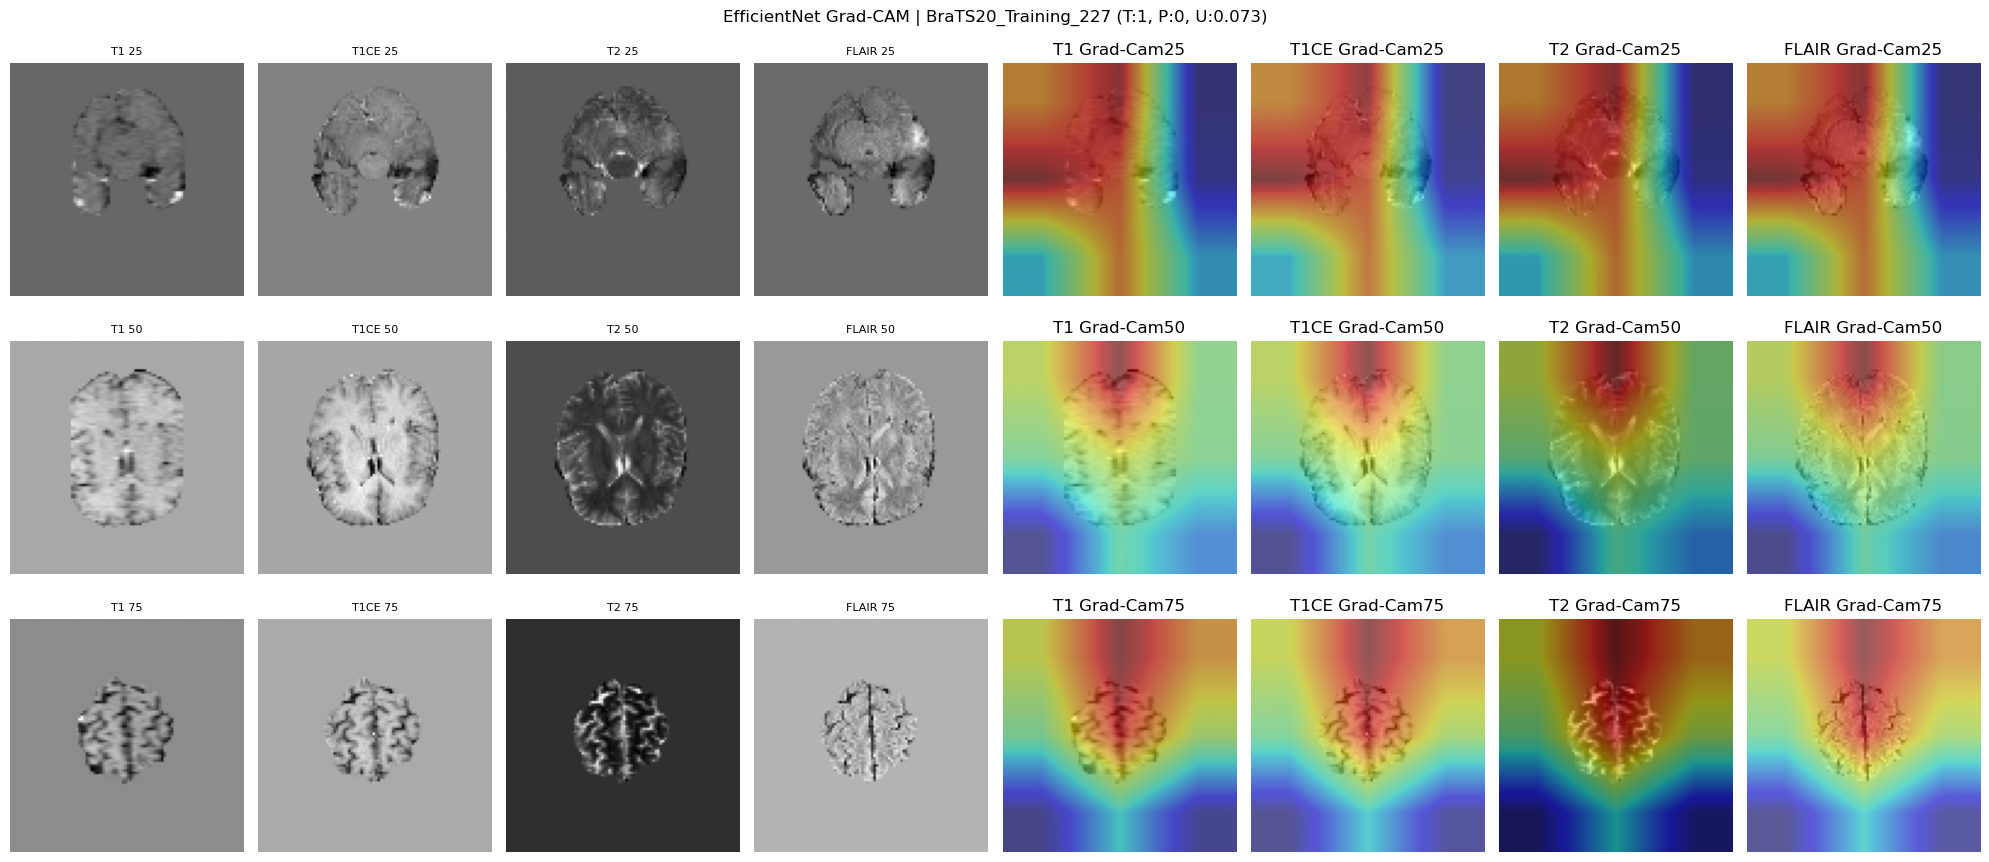

In [35]:
names = ["T1", "T1CE", "T2", "FLAIR"]

slices = [25, 50, 75]

rows = len(slices)

cols = 8

plt.figure(figsize = (20, 3 * rows))

patient = test_df.iloc[eff_sample_indexes[0]]["patient"]
    
mri = eff_mris[0]
    
cam = eff_cams[0]
    
for r, s in enumerate(slices):
		
	for c in range(4):
		
		plt.subplot(rows, cols, r * cols + c + 1)
		
		plt.imshow(mri[c, s].T, cmap = "gray", origin = "lower")
		
		plt.title(f"{names[c]} {s}", fontsize = 8)
		
		plt.axis("off")
		
		plt.subplot(rows, cols, r * cols + c + 5)
		
		plt.imshow(mri[c, s].T, cmap = "gray", origin = "lower")
		
		plt.imshow(cam[s].T, cmap = "jet", alpha = 0.5, origin = "lower")
		
		plt.title(f"{names[c]} Grad-Cam{s}")
		
		plt.axis("off")


plt.suptitle(
    f"EfficientNet Grad-CAM | "
    f"{patient} "
    f"(T:{int(eff_labels[0])}, "
    f"P:{eff_predictions[0]}, "
    f"U:{eff_mc_uncertainty[eff_sample_indexes[0]]:.3f})"
)

plt.tight_layout()

plt.savefig(
f"Results/Figures/ViT/GradCAM/{patient}.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

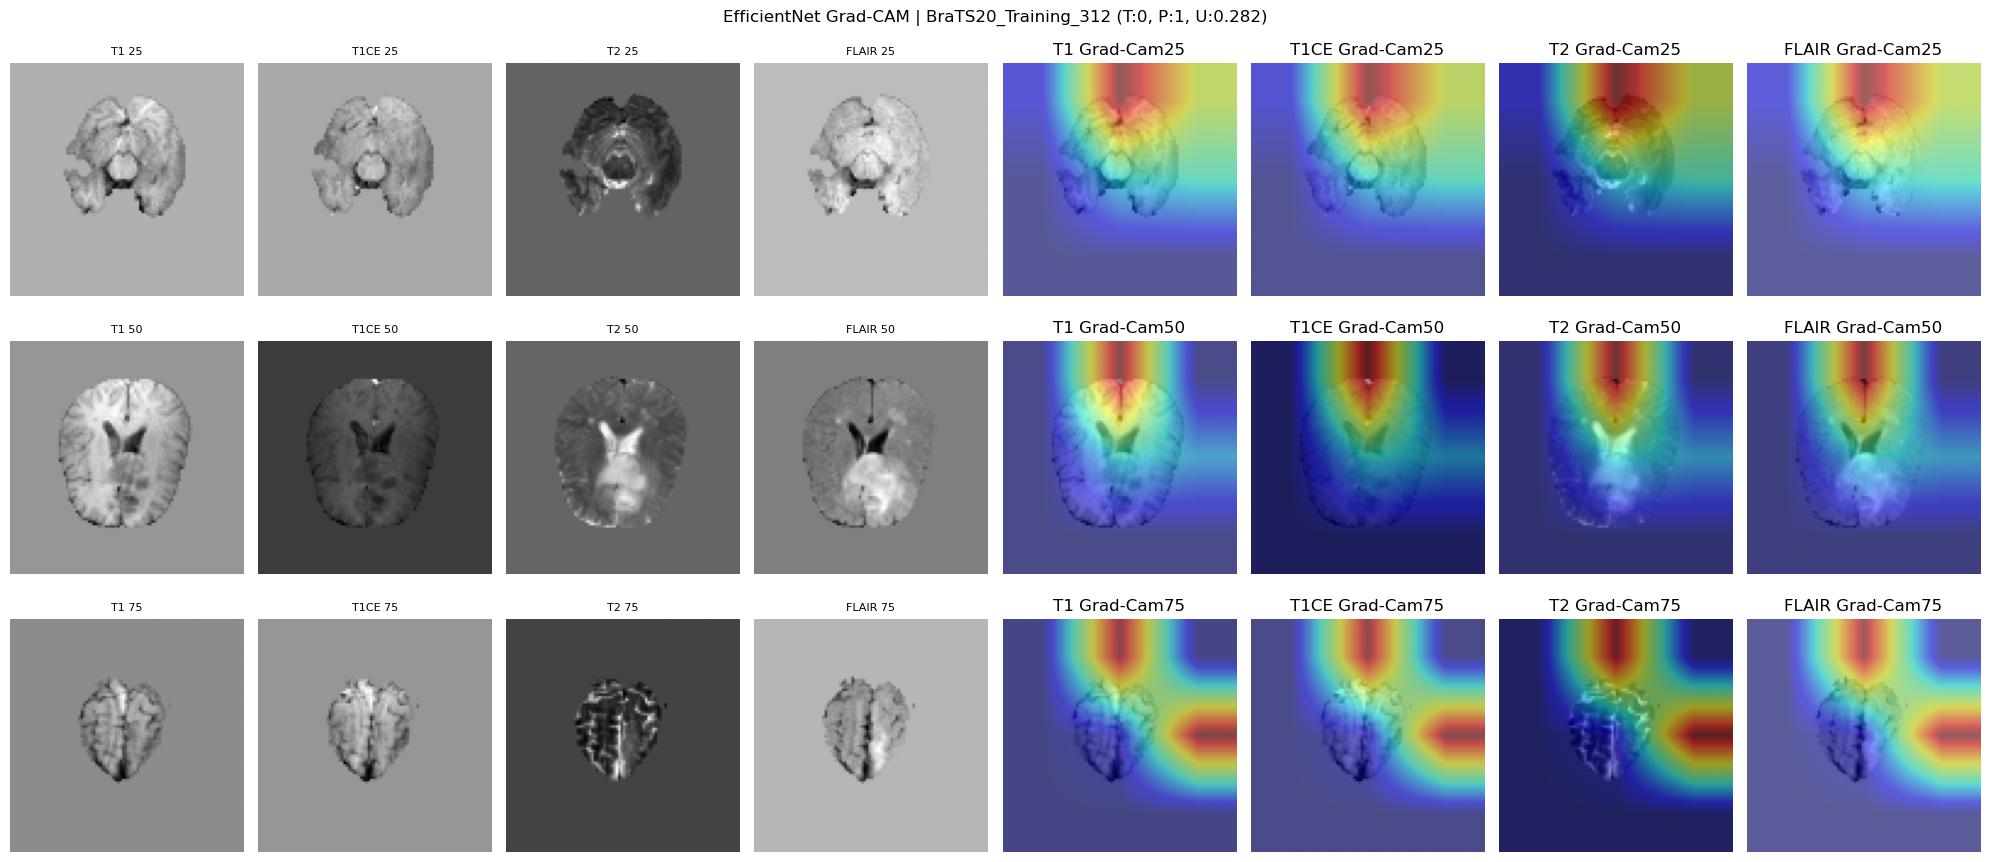

In [36]:
names = ["T1", "T1CE", "T2", "FLAIR"]

slices = [25, 50, 75]

rows = len(slices)

cols = 8

plt.figure(figsize = (20, 3 * rows))

patient = test_df.iloc[eff_sample_indexes[1]]["patient"]
    
mri = eff_mris[1]
    
cam = eff_cams[1]
    
for r, s in enumerate(slices):
		
	for c in range(4):
		
		plt.subplot(rows, cols, r * cols + c + 1)
		
		plt.imshow(mri[c, s].T, cmap = "gray", origin = "lower")
		
		plt.title(f"{names[c]} {s}", fontsize = 8)
		
		plt.axis("off")
		
		plt.subplot(rows, cols, r * cols + c + 5)
		
		plt.imshow(mri[c, s].T, cmap = "gray", origin = "lower")
		
		plt.imshow(cam[s].T, cmap = "jet", alpha = 0.5, origin = "lower")
		
		plt.title(f"{names[c]} Grad-Cam{s}")
		
		plt.axis("off")


plt.suptitle(
    f"EfficientNet Grad-CAM | "
    f"{patient} "
    f"(T:{int(eff_labels[1])}, "
    f"P:{eff_predictions[1]}, "
    f"U:{eff_mc_uncertainty[eff_sample_indexes[1]]:.3f})"
)

plt.tight_layout()

plt.savefig(
f"Results/Figures/ViT/GradCAM/{patient}.png",
dpi=300,
bbox_inches="tight"
)

plt.show()